In [11]:

# analiza podataka
import pandas as pd
import numpy as np

# vizualizacija
import seaborn as sns
import matplotlib.pyplot as plt

# priprema i modeliranje
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB

# evaluacija
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)


In [12]:
files = [
    "../data/FuelData/2025-12-01-31/f1.csv",
    "../data/FuelData/2026-01-01-31/f2.csv",
    "../data/FuelData/2026-02-01-28/f3.csv",
    "../data/FuelData/2026-03-01-23/f4.csv",
]

dfs = [pd.read_csv(f, sep=";", dtype=str, encoding="utf-8-sig") for f in files]
merged = pd.concat(dfs, ignore_index=True)
merged.to_csv("../data/FuelData/fuel_data_final.csv", sep=";", index=False, encoding="utf-8-sig")

In [14]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1187100 entries, 0 to 1187099
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   obj_id          1187100 non-null  object
 1   time            1187100 non-null  object
 2   fuel_lvl        1187100 non-null  object
 3   withdrawl_flag  1187100 non-null  object
 4   speed           1187100 non-null  object
 5   contact_value   1187100 non-null  object
 6   gps_latitude    1187082 non-null  object
 7   gps_longitude   1187082 non-null  object
dtypes: object(8)
memory usage: 72.5+ MB


In [16]:
# Konverzija stupca 'time' u datetime format
merged['time'] = pd.to_datetime(merged['time'])

# Konverzija koordinata: zamjena zareza točkom i pretvorba u float
merged['gps_latitude'] = merged['gps_latitude'].str.replace(',', '.').astype(float)
merged['gps_longitude'] = merged['gps_longitude'].str.replace(',', '.').astype(float)

# Provjera tipova podataka i prvih nekoliko redaka
print(merged.dtypes)
display(merged.head())

obj_id                    object
time              datetime64[ns]
fuel_lvl                  object
withdrawl_flag            object
speed                     object
contact_value             object
gps_latitude             float64
gps_longitude            float64
dtype: object


,obj_id,time,fuel_lvl,withdrawl_flag,speed,contact_value,gps_latitude,gps_longitude
0,2484,2025-12-08 13:39:00,144,0,0,-,45.792643,17.001076
1,2484,2025-12-08 13:40:00,144,0,0,-,45.792643,17.001076
2,2484,2025-12-08 13:41:00,144,0,29,-,45.793414,17.316811
3,2484,2025-12-08 13:42:00,144,0,37,-,45.801079,16.994503
4,2484,2025-12-08 13:43:00,144,0,3,-,45.802589,16.995177


In [17]:
# Provjera jedinstvenih vrijednosti i njihove učestalosti
print("Jedinstvene vrijednosti u contact_value:")
print(merged['contact_value'].unique())

print("\nBroj pojavljivanja svake vrijednosti:")
print(merged['contact_value'].value_counts())

# Provjera nedostajućih vrijednosti
print("\nBroj null vrijednosti:", merged['contact_value'].isnull().sum())

Jedinstvene vrijednosti u contact_value:
['-' 'Neaktivan' 'Aktivan']

Broj pojavljivanja svake vrijednosti:
contact_value
Aktivan      668709
Neaktivan    348891
-            169500
Name: count, dtype: int64

Broj null vrijednosti: 0


In [18]:
display(merged[merged['contact_value'] == 'Neaktivan'].head())

,obj_id,time,fuel_lvl,withdrawl_flag,speed,contact_value,gps_latitude,gps_longitude
2280,7935,2025-12-15 18:49:00,398,0,0,Neaktivan,45.808984,15.869859
2281,7935,2025-12-15 18:50:00,398,0,0,Neaktivan,45.808984,15.869859
2282,7935,2025-12-15 18:51:00,398,0,0,Neaktivan,45.808984,15.869859
2283,7935,2025-12-15 18:52:00,398,0,0,Neaktivan,45.808984,15.869859
2284,7935,2025-12-15 18:53:00,398,0,0,Neaktivan,45.808984,15.869859


C:\Users\david\AppData\Local\Temp\ipykernel_32420\777875815.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_plot, x='fuel_bins', ax=axes[0, 0], palette='viridis')
C:\Users\david\AppData\Local\Temp\ipykernel_32420\777875815.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_plot, x='withdrawl_flag', ax=axes[0, 1], palette='Set2')
C:\Users\david\AppData\Local\Temp\ipykernel_32420\777875815.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_plot, x='contact_value', ax=axes[1, 0], palette='coolw

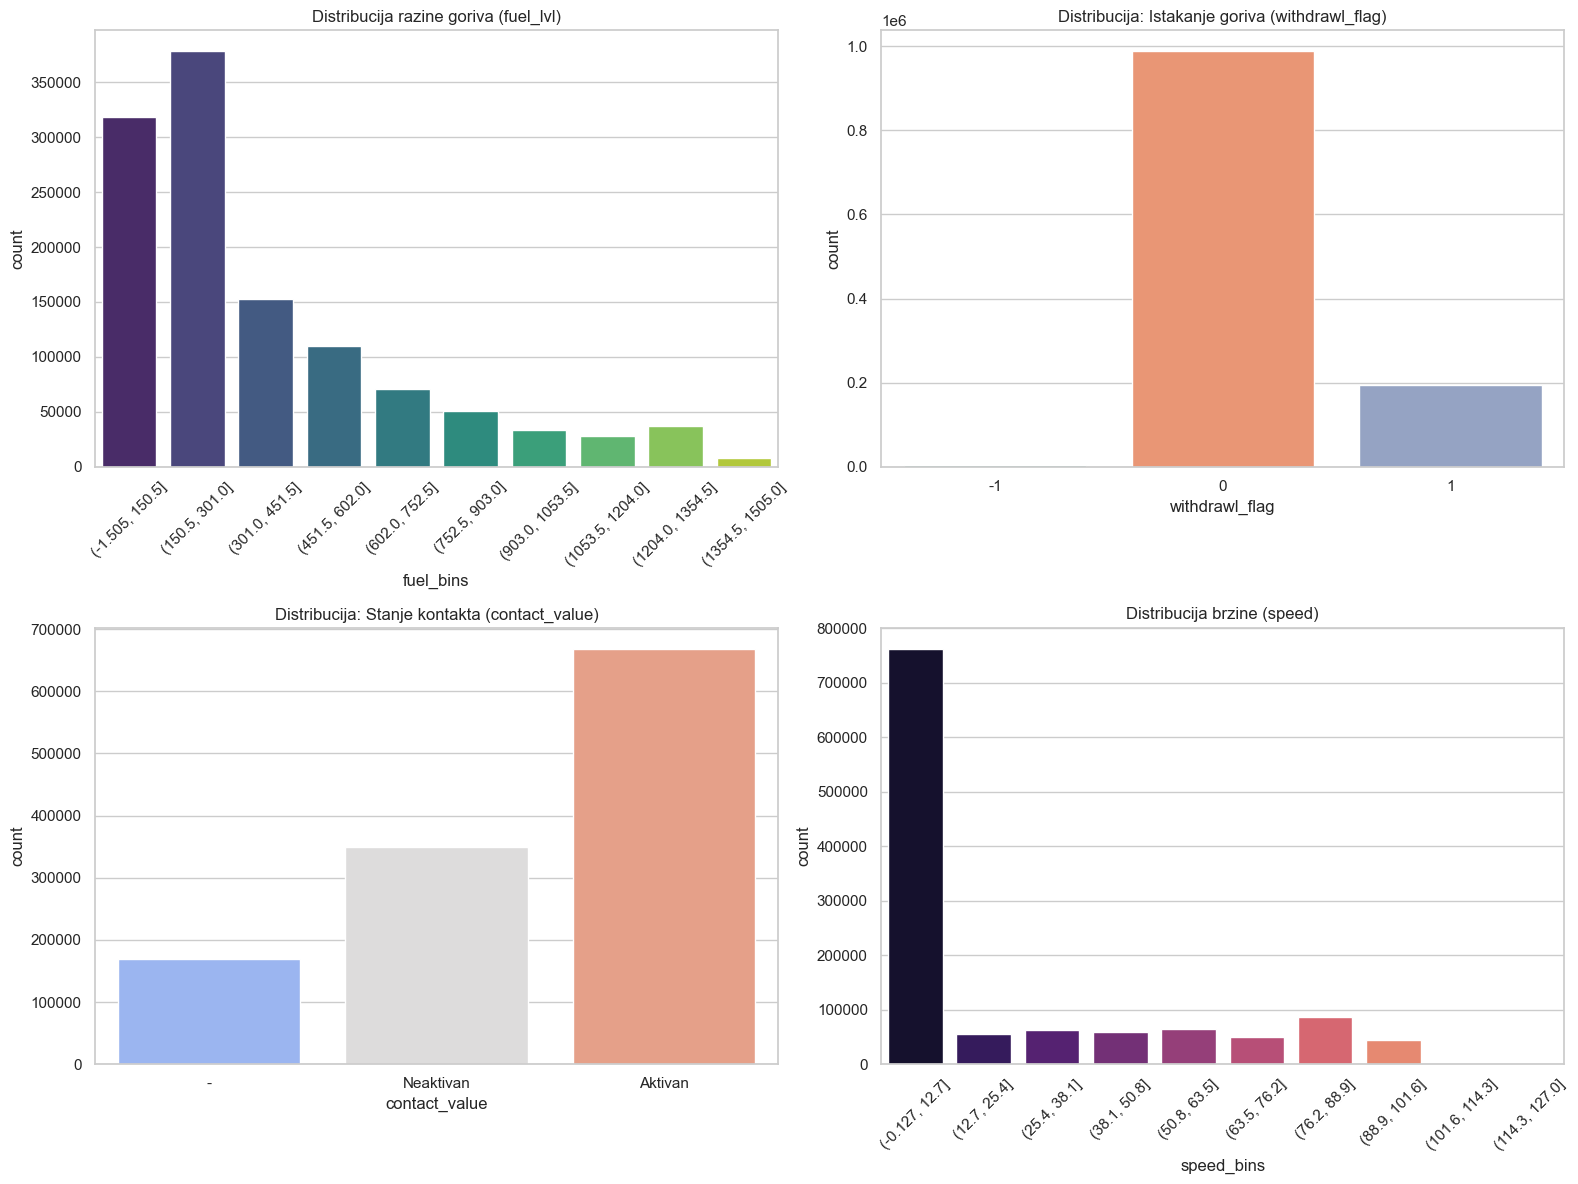

In [21]:

import matplotlib.pyplot as plt
import seaborn as sns

merged['fuel_lvl'] = pd.to_numeric(merged['fuel_lvl'], errors='coerce')
merged['speed'] = pd.to_numeric(merged['speed'], errors='coerce')
merged['withdrawl_flag'] = pd.to_numeric(merged['withdrawl_flag'], errors='coerce')

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

merged_plot = merged.dropna(subset=['fuel_lvl', 'speed', 'withdrawl_flag']).copy()

merged_plot['fuel_bins'] = pd.cut(merged_plot['fuel_lvl'], bins=10)
sns.countplot(data=merged_plot, x='fuel_bins', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Distribucija razine goriva (fuel_lvl)')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.countplot(data=merged_plot, x='withdrawl_flag', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Distribucija: Istakanje goriva (withdrawl_flag)')

sns.countplot(data=merged_plot, x='contact_value', ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Distribucija: Stanje kontakta (contact_value)')

merged_plot['speed_bins'] = pd.cut(merged_plot['speed'], bins=10)
sns.countplot(data=merged_plot, x='speed_bins', ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Distribucija brzine (speed)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [25]:
num_cols = ['fuel_lvl', 'withdrawl_flag', 'speed']
for col in num_cols:
    merged[col] = pd.to_numeric(merged[col], errors='coerce')
print(merged[num_cols].describe())

           fuel_lvl  withdrawl_flag         speed
count  1.187100e+06    1.187100e+06  1.187100e+06
mean   3.722335e+02    1.604574e-01  2.084240e+01
std    3.164316e+02    3.771743e-01  3.072252e+01
min    0.000000e+00   -1.000000e+00  0.000000e+00
25%    1.420000e+02    0.000000e+00  0.000000e+00
50%    2.680000e+02    0.000000e+00  0.000000e+00
75%    4.950000e+02    0.000000e+00  4.000000e+01
max    1.505000e+03    1.000000e+00  1.270000e+02


In [23]:
# Pronalaženje redaka gdje je withdrawl_flag -1
withdrawl_minus_1 = merged[merged['withdrawl_flag'] == -1]

print(f"Broj redaka s withdrawl_flag = -1: {len(withdrawl_minus_1)}")
display(withdrawl_minus_1.head())

Broj redaka s withdrawl_flag = -1: 4481


,obj_id,time,fuel_lvl,withdrawl_flag,speed,contact_value,gps_latitude,gps_longitude
3990,13886,2025-12-19 11:25:00,130,-1,0,Neaktivan,45.897835,16.201183
3991,13886,2025-12-19 11:26:00,125,-1,0,Neaktivan,45.897835,16.201191
3992,13886,2025-12-19 11:27:00,123,-1,0,Neaktivan,45.897849,16.201202
3993,13886,2025-12-19 11:27:00,123,-1,0,Neaktivan,45.897849,16.201202
7590,28161,2025-12-15 11:53:00,253,-1,8,Aktivan,49.581093,14.568910


In [27]:
# Analiza korelacije withdrawl_flag-a s promjenom razine goriva
print("Prosječna razina goriva po withdrawl_flag:")
display(merged.groupby('withdrawl_flag')['fuel_lvl'].mean())

# Provjera stanja kontakta za vrijednost -1
print("\nStanje kontakta za withdrawl_flag = -1:")
display(merged[merged['withdrawl_flag'] == -1]['contact_value'].value_counts())

Prosječna razina goriva po withdrawl_flag:


withdrawl_flag
-1    310.426021
 0    346.644882
 1    503.284971
Name: fuel_lvl, dtype: float64


Stanje kontakta za withdrawl_flag = -1:


contact_value
Aktivan      1847
Neaktivan    1481
-            1153
Name: count, dtype: int64

In [28]:
# Definiranje značajki
numerical_features = ['fuel_lvl', 'speed', 'gps_latitude', 'gps_longitude']
categorical_features = ['contact_value']

# Pipeline za numeričke značajke: Imputacija medijanom + Standardizacija
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline za kategoričke značajke: Imputacija najčešćom vrijednošću + One-Hot Encoding
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Spajanje u ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_features),
        ('cat', cat_transformer, categorical_features)
    ]
)

# Prikaz preprocesora
print("Preprocessing pipeline je definiran.")
display(preprocessor)

Preprocessing pipeline je definiran.


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [29]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1187100 entries, 0 to 1187099
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   obj_id          1187100 non-null  object        
 1   time            1187100 non-null  datetime64[ns]
 2   fuel_lvl        1187100 non-null  int64         
 3   withdrawl_flag  1187100 non-null  int64         
 4   speed           1187100 non-null  int64         
 5   contact_value   1187100 non-null  object        
 6   gps_latitude    1187082 non-null  float64       
 7   gps_longitude   1187082 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 72.5+ MB


In [30]:
# Definiranje značajki (X) i ciljne varijable (y)
X = merged.drop(columns=['withdrawl_flag', 'time', 'obj_id'])
y = merged['withdrawl_flag']

# Podjela na trening i test skup (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print(f"Veličina skupa za treniranje: {X_train.shape[0]} redaka")
print(f"Veličina skupa za testiranje: {X_test.shape[0]} redaka")

Veličina skupa za treniranje: 830970 redaka
Veličina skupa za testiranje: 356130 redaka


In [31]:
# Uzorkovanje 200,000 zapisa
merged_sample_200 = merged.sample(n=200000, random_state=42)
X_s2 = merged_sample_200.drop(columns=['withdrawl_flag', 'time', 'obj_id'])
y_s2 = merged_sample_200['withdrawl_flag']

# Podjela na trening i test (70/30)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_s2, y_s2, test_size=0.30, random_state=42, stratify=y_s2)

# Definiranje i treniranje modela
nb_pipeline_200 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

nb_pipeline_200.fit(X_train_2, y_train_2)

# Predviđanje i evaluacija
y_pred_200 = nb_pipeline_200.predict(X_test_2)
y_proba_200 = nb_pipeline_200.predict_proba(X_test_2)

# Izračun metrika
accuracy = accuracy_score(y_test_2, y_pred_200)
precision = precision_score(y_test_2, y_pred_200, average='weighted', zero_division=0)
recall = recall_score(y_test_2, y_pred_200, average='weighted')
f1 = f1_score(y_test_2, y_pred_200, average='weighted')
roc_auc = roc_auc_score(y_test_2, y_proba_200, multi_class='ovr')

# Prikaz rezultata u traženom formatu
print("--- Rezultati Naivnog Bayesa ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_2, y_pred_200))

--- Rezultati Naivnog Bayesa ---
Accuracy:  0.7295
Precision: 0.8093
Recall:    0.7295
F1-score:  0.7561
ROC AUC:   0.7540

Classification Report:
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00       230
           0       0.91      0.75      0.82     49890
           1       0.33      0.63      0.43      9880

    accuracy                           0.73     60000
   macro avg       0.41      0.46      0.42     60000
weighted avg       0.81      0.73      0.76     60000



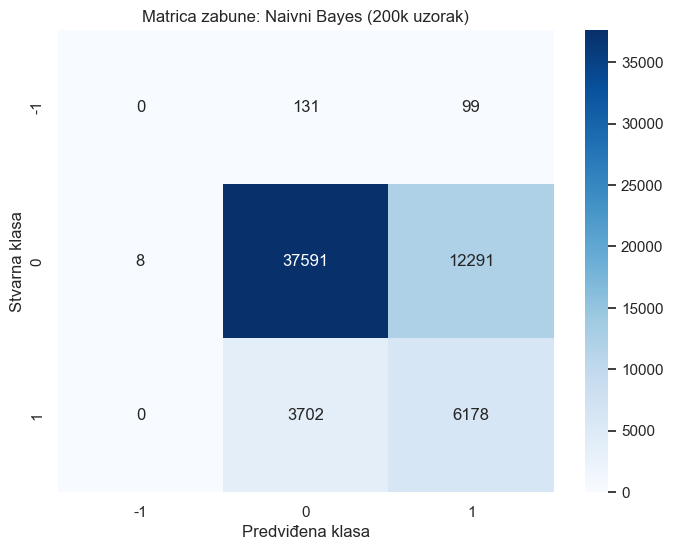

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Definiranje oznaka klasa na temelju y_test_2
labels = sorted(y_test_2.unique())

# Izračun matrice zabune
cm_nb_200 = confusion_matrix(y_test_2, y_pred_200, labels=labels)

# Vizualizacija
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb_200, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Matrica zabune: Naivni Bayes (200k uzorak)')
plt.xlabel('Predviđena klasa')
plt.ylabel('Stvarna klasa')
plt.show()

Naivni Bayes ne funkcionira dobro sa neuravnoteženim podacima poput onih u withdrawl_flag gdje klasa -1 ima samo 1344 primjera.Pokušati ćemo sa Random Forest algoritmom.

--- Rezultati Random Foresta ---
Accuracy:  0.9090
Precision: 0.9036
Recall:    0.9090
F1-score:  0.9041
ROC AUC:   0.9031

Classification Report:
              precision    recall  f1-score   support

          -1       0.56      0.20      0.29       230
           0       0.93      0.97      0.95     49890
           1       0.79      0.63      0.70      9880

    accuracy                           0.91     60000
   macro avg       0.76      0.60      0.65     60000
weighted avg       0.90      0.91      0.90     60000



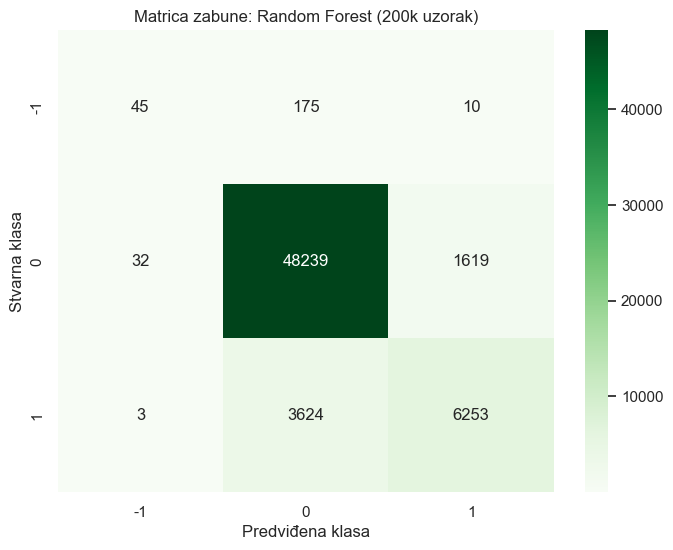

In [33]:
from sklearn.ensemble import RandomForestClassifier

# Definiranje i treniranje Random Forest modela na 200k uzorku
rf_pipeline_200 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_pipeline_200.fit(X_train_2, y_train_2)

# Predviđanje i evaluacija
y_pred_rf_200 = rf_pipeline_200.predict(X_test_2)
y_proba_rf_200 = rf_pipeline_200.predict_proba(X_test_2)

# Izračun metrika
accuracy_rf = accuracy_score(y_test_2, y_pred_rf_200)
precision_rf = precision_score(y_test_2, y_pred_rf_200, average='weighted', zero_division=0)
recall_rf = recall_score(y_test_2, y_pred_rf_200, average='weighted')
f1_rf = f1_score(y_test_2, y_pred_rf_200, average='weighted')
roc_auc_rf = roc_auc_score(y_test_2, y_proba_rf_200, multi_class='ovr')

# Prikaz rezultata
print("--- Rezultati Random Foresta ---")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-score:  {f1_rf:.4f}")
print(f"ROC AUC:   {roc_auc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_2, y_pred_rf_200))

# Matrica zabune
plt.figure(figsize=(8, 6))
cm_rf_200 = confusion_matrix(y_test_2, y_pred_rf_200, labels=labels)
sns.heatmap(cm_rf_200, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title('Matrica zabune: Random Forest (200k uzorak)')
plt.xlabel('Predviđena klasa')
plt.ylabel('Stvarna klasa')
plt.show()

In [36]:
import sys
print(sys.executable)

c:\Users\david\miniconda3\python.exe


c:\Users\david\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:45:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Rezultati XGBoosta ---
Accuracy:  0.8846
Precision: 0.8752
Recall:    0.8846
F1-score:  0.8745
ROC AUC:   0.9140

Classification Report:
              precision    recall  f1-score   support

          -1       0.74      0.09      0.16       230
           0       0.90      0.96      0.93     49890
           1       0.73      0.50      0.60      9880

    accuracy                           0.88     60000
   macro avg       0.79      0.52      0.56     60000
weighted avg       0.88      0.88      0.87     60000



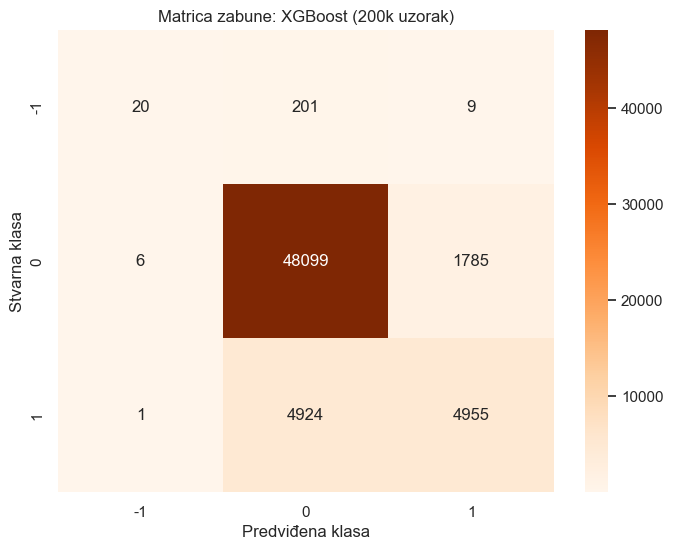

In [37]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost zahtijeva da klase počinju od 0 (npr. 0, 1, 2)
le_200 = LabelEncoder()
y_train_xgb_200 = le_200.fit_transform(y_train_2)
y_test_xgb_200 = le_200.transform(y_test_2)

# Kreiranje XGBoost modela u pipelineu
xgb_pipeline_200 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss'))
])

# Treniranje
xgb_pipeline_200.fit(X_train_2, y_train_xgb_200)

# Predviđanje i vjerojatnosti
y_pred_xgb_200 = xgb_pipeline_200.predict(X_test_2)
y_proba_xgb_200 = xgb_pipeline_200.predict_proba(X_test_2)

# Izračun metrika
accuracy_xgb = accuracy_score(y_test_xgb_200, y_pred_xgb_200)
precision_xgb = precision_score(y_test_xgb_200, y_pred_xgb_200, average='weighted', zero_division=0)
recall_xgb = recall_score(y_test_xgb_200, y_pred_xgb_200, average='weighted')
f1_xgb = f1_score(y_test_xgb_200, y_pred_xgb_200, average='weighted')
roc_auc_xgb = roc_auc_score(y_test_xgb_200, y_proba_xgb_200, multi_class='ovr')

# Prikaz rezultata
print("--- Rezultati XGBoosta ---")
print(f"Accuracy:  {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall:    {recall_xgb:.4f}")
print(f"F1-score:  {f1_xgb:.4f}")
print(f"ROC AUC:   {roc_auc_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_xgb_200, y_pred_xgb_200, target_names=[str(c) for c in le_200.classes_]))

# Matrica zabune
plt.figure(figsize=(8, 6))
cm_xgb_200 = confusion_matrix(y_test_xgb_200, y_pred_xgb_200)
sns.heatmap(cm_xgb_200, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_200.classes_, yticklabels=le_200.classes_)
plt.title('Matrica zabune: XGBoost (200k uzorak)')
plt.xlabel('Predviđena klasa')
plt.ylabel('Stvarna klasa')
plt.show()

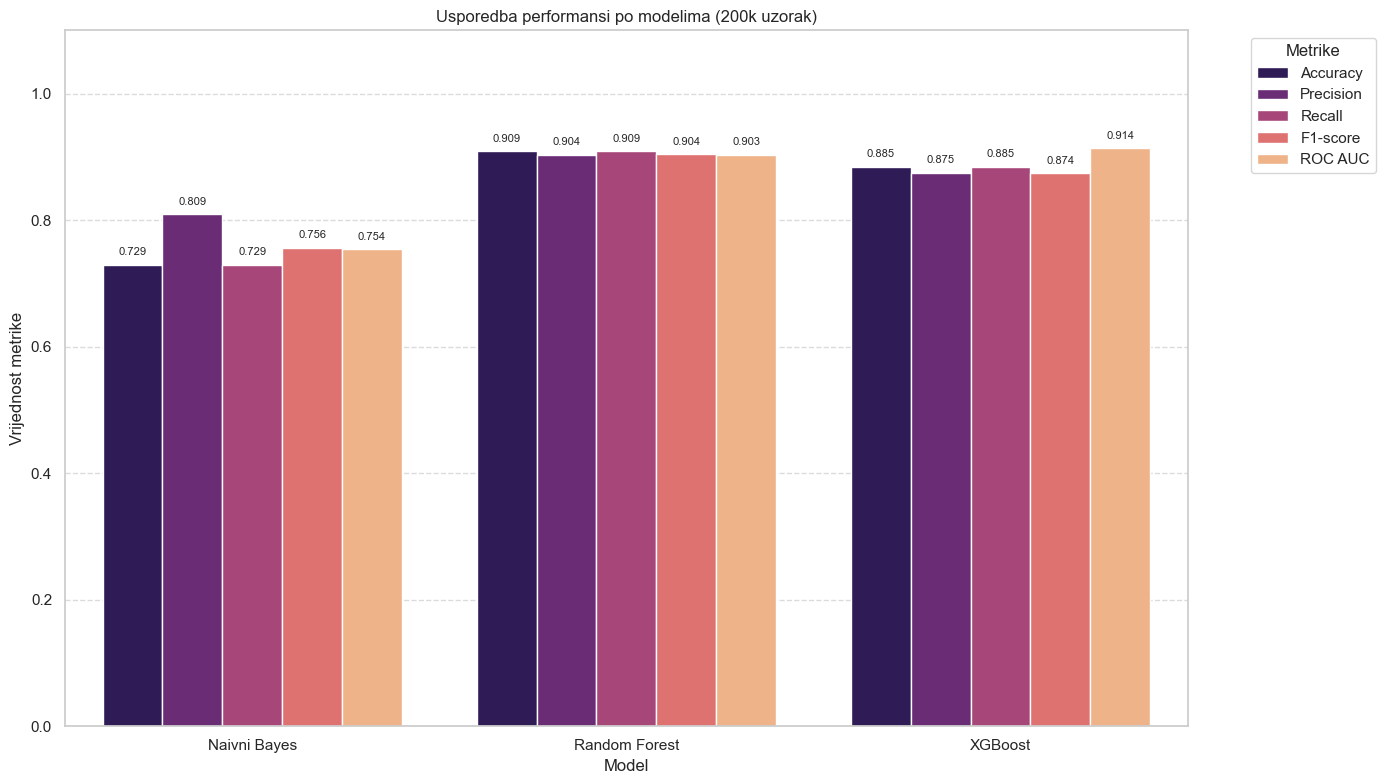

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Osiguravanje da su podaci u ispravnom formatu za vizualizaciju
comparison_data = {
    'Model': ['Naivni Bayes', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy, accuracy_rf, accuracy_xgb],
    'Precision': [precision, precision_rf, precision_xgb],
    'Recall': [recall, recall_rf, recall_xgb],
    'F1-score': [f1, f1_rf, f1_xgb],
    'ROC AUC': [roc_auc, roc_auc_rf, roc_auc_xgb]
}
df_comparison = pd.DataFrame(comparison_data)
df_melted = df_comparison.melt(id_vars='Model', var_name='Metrika', value_name='Vrijednost')

# Vizualizacija s modelima na X-osi prema vašem kodu
plt.figure(figsize=(14, 8))
sns.barplot(data=df_melted, x='Model', y='Vrijednost', hue='Metrika', palette='magma')

plt.title('Usporedba performansi po modelima (200k uzorak)')
plt.ylim(0, 1.1)
plt.ylabel('Vrijednost metrike')
plt.xlabel('Model')
plt.legend(title='Metrike', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Dodavanje vrijednosti iznad stupaca
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f'{p.get_height():.3f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha = 'center', va = 'center',
                       xytext = (0, 9),
                       textcoords = 'offset points',
                       fontsize=8,
                       rotation=0)

plt.tight_layout()
plt.show()